# 🧑‍🏫 Aula 1 — Pipeline de Machine Learning End-to-End com MLflow

**UC:** Machine Learning | **Data:** 15/04/2026 | **Duração:** 3 horas

---

## 🎯 Objetivos desta Aula

Nesta aula você vai aprender a construir um **pipeline completo de Machine Learning**, desde o carregamento dos dados até a exportação do modelo treinado. Vamos usar o caso de uma **indústria têxtil** que precisa classificar a qualidade dos tecidos produzidos em **Low**, **Medium** e **High**.

### O que é um Pipeline de ML?

```
📥 Coleta de Dados → 🔍 EDA → 🧹 Pré-processamento → 🔀 Divisão Treino/Teste → 🤖 Treinamento → 📊 Avaliação → 💾 Exportação
```

### O que é o MLflow?

O **MLflow** é uma plataforma open-source para gerenciar o ciclo de vida de Machine Learning. Ele permite:
- **Registrar parâmetros** (hiperparâmetros do modelo)
- **Registrar métricas** (accuracy, F1-score, etc.)
- **Salvar artefatos** (gráficos, modelos, datasets)
- **Comparar experimentos** lado a lado

> 💡 **Por que isso importa?** Na indústria, você vai treinar centenas de modelos diferentes. Sem tracking, é impossível saber qual configuração gerou o melhor resultado.

---

📦 **Dataset:** [Textile Fabric Quality Classification](https://www.kaggle.com/datasets/devendrakushwah08/textile-fabric-quality-classification-dataset) — 25K amostras de inspeção de qualidade de tecido

## 1️⃣ Configuração do Ambiente e Importação de Bibliotecas

Primeiro, vamos instalar e importar tudo que precisamos. Cada biblioteca tem um papel específico no pipeline:

| Biblioteca | Para que serve |
|---|---|
| `pandas` | Manipulação de dados em tabelas (DataFrames) |
| `numpy` | Operações matemáticas e arrays |
| `matplotlib` / `seaborn` | Criação de gráficos e visualizações |
| `scikit-learn` | Algoritmos de ML, métricas, pré-processamento |
| `mlflow` | Tracking de experimentos (parâmetros, métricas, modelos) |
| `joblib` | Salvar/carregar modelos em disco |

In [1]:
# ============================================================
# INSTALAÇÃO DAS DEPENDÊNCIAS
# ============================================================
# O comando abaixo instala todas as bibliotecas necessárias.
# O "!" no início executa o comando no terminal diretamente do notebook.
# -q = modo silencioso (menos output na tela)

!pip install -q pandas numpy matplotlib seaborn scikit-learn mlflow xgboost kagglehub

In [2]:
# ============================================================
# IMPORTAÇÃO DAS BIBLIOTECAS
# ============================================================

# --- Manipulação de Dados ---
import pandas as pd                  # Trabalhar com tabelas (DataFrames)
import numpy as np                   # Operações matemáticas

# --- Visualização ---
import matplotlib.pyplot as plt      # Criação de gráficos
import seaborn as sns                # Gráficos estatísticos mais bonitos

# --- Machine Learning (scikit-learn) ---
from sklearn.model_selection import train_test_split    # Dividir dados em treino/teste
from sklearn.preprocessing import LabelEncoder          # Converter texto em números
from sklearn.preprocessing import StandardScaler        # Padronizar escala das features
from sklearn.ensemble import RandomForestClassifier     # Nosso modelo de classificação
from sklearn.metrics import (                           # Métricas de avaliação
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# --- Tracking de Experimentos ---
import mlflow                        # Plataforma de tracking de ML
import mlflow.sklearn                # Integração MLflow com scikit-learn

# --- Salvar/Carregar Modelos ---
import joblib                        # Serialização eficiente de modelos
import os                            # Operações com sistema de arquivos
import warnings
warnings.filterwarnings('ignore')    # Silenciar avisos para manter o notebook limpo

# Configuração visual dos gráficos
plt.style.use('seaborn-v0_8-whitegrid')  # Estilo limpo e profissional
sns.set_palette('husl')                   # Paleta de cores agradável

print("✅ Todas as bibliotecas foram importadas com sucesso!")

✅ Todas as bibliotecas foram importadas com sucesso!


## 2️⃣ Configuração do MLflow Tracking

O MLflow funciona como um **diário de bordo** dos seus experimentos. Cada vez que você treina um modelo, ele registra:

- **Parâmetros:** as configurações usadas (ex: `n_estimators=100`)
- **Métricas:** os resultados obtidos (ex: `accuracy=0.85`)
- **Artefatos:** arquivos gerados (ex: gráfico da confusion matrix, modelo salvo)

Tudo fica organizado em **Experiments** (grupos de experimentos) e **Runs** (execuções individuais).

> 🏭 **Analogia industrial:** Imagine que cada Run é uma "receita" diferente para produzir tecido. O MLflow é o caderno onde você anota todas as receitas e seus resultados de qualidade.

In [3]:
# ============================================================
# CONFIGURAÇÃO DO MLFLOW
# ============================================================

# Define onde o MLflow vai salvar os dados dos experimentos.
# Usamos SQLite como backend — é mais robusto que a pasta local (./mlruns)
# e compatível com todas as features modernas do MLflow.
# O "///" indica caminho relativo; "../mlflow.db" salva na raiz do projeto.
# Em produção, isso apontaria para um servidor remoto.
mlflow.set_tracking_uri("sqlite:///../mlflow.db")

# Cria (ou reutiliza) um experimento chamado 'aula01_qualidade_textil'.
# Todos os runs desta aula ficarão agrupados neste experimento.
mlflow.set_experiment("aula01_qualidade_textil")

print("✅ MLflow configurado!")
print(f"   📁 Tracking URI: {mlflow.get_tracking_uri()}")
print(f"   🧪 Experimento: aula01_qualidade_textil")

2026/04/15 20:09:36 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/04/15 20:09:36 INFO mlflow.store.db.utils: Updating database tables
2026/04/15 20:09:39 INFO mlflow.tracking.fluent: Experiment with name 'aula01_qualidade_textil' does not exist. Creating a new experiment.


✅ MLflow configurado!
   📁 Tracking URI: sqlite:///../mlflow.db
   🧪 Experimento: aula01_qualidade_textil


## 3️⃣ Carregamento do Dataset de Qualidade Têxtil

Vamos trabalhar com o dataset **Textile Fabric Quality Classification** do Kaggle. Ele contém **~25.000 amostras** de inspeção de tecido com **23 colunas** de características.

### Contexto Industrial 🏭
Em uma fábrica têxtil, cada rolo de tecido passa por uma **inspeção de qualidade** onde são medidos:
- **Thread count** (contagem de fios)
- **GSM** (gramatura — peso por metro²)
- **Tensile strength** (resistência à tração)
- **Shrinkage** (encolhimento)
- **Defect count** (número de defeitos)
- E muitas outras propriedades...

Com base nessas medições, o tecido é classificado como: **Low** (baixa), **Medium** (média) ou **High** (alta) qualidade.

In [5]:
# ============================================================
# DOWNLOAD DO DATASET VIA KAGGLEHUB
# ============================================================
# O kagglehub baixa automaticamente datasets do Kaggle.
# Na primeira execução, pode pedir suas credenciais do Kaggle.
# Alternativa: baixe manualmente do link e coloque o CSV nesta pasta.

import kagglehub

# Baixa o dataset e retorna o caminho local onde foi salvo
dataset_path = kagglehub.dataset_download(
    "devendrakushwah08/textile-fabric-quality-classification-dataset"
)

print(f"✅ Dataset baixado em: {dataset_path}")

# Lista os arquivos baixados para encontrar o CSV
for arquivo in os.listdir(dataset_path):
    print(f"   📄 {arquivo}")

100%|██████████| 2.34M/2.34M [00:01<00:00, 2.35MB/s]

Extracting files...
✅ Dataset baixado em: C:\Users\50812123859\.cache\kagglehub\datasets\devendrakushwah08\textile-fabric-quality-classification-dataset\versions\1
   📄 Industrial Fabric Quality Inspection Dataset.csv


In [6]:
# ============================================================
# CARREGAMENTO DO CSV EM UM DATAFRAME
# ============================================================
# O pandas.read_csv() lê o arquivo CSV e transforma em uma tabela (DataFrame).

# Encontra o arquivo CSV no diretório baixado
csv_files = [f for f in os.listdir(dataset_path) if f.endswith('.csv')]
csv_path = os.path.join(dataset_path, csv_files[0])

# Carrega o dataset
df = pd.read_csv(csv_path)

# --- Primeiras linhas: como são nossos dados? ---
print(f"📊 Dataset carregado com sucesso!")
print(f"   Linhas: {df.shape[0]:,}")    # :, formata número com separador de milhar
print(f"   Colunas: {df.shape[1]}")
print(f"\n🔍 Primeiras 5 linhas do dataset:")
df.head()

📊 Dataset carregado com sucesso!
   Linhas: 25,750
   Colunas: 23

🔍 Primeiras 5 linhas do dataset:


,thread_count,gsm,tensile_strength,shrinkage_percent,color_fastness,fabric_thickness,defect_count,elongation_percent,moisture_absorption,fabric_type,...,batch_id,roll_number,inspection_time_minutes,warehouse_id,operator_name,inspection_shift,machine_temperature,humidity_level,inspection_notes,fabric_quality
0,166.0,383.0,NaN,7.744704,1,0.891865,11,31.299228,12.855777,polyester,...,898423,363,45.957289,WH-A,Suresh,Morning,28.148868,67.810041,Recheck,Low
1,273.0,107.0,106.508682,1.191272,1,0.872380,4,8.092515,7.224689,polyester,...,350678,4741,33.035982,WH-C,Suresh,Morning,42.033282,40.596520,Looks fine,High
2,274.0,352.0,97.100410,NaN,3,1.231906,3,24.134907,12.276679,silk,...,195742,1626,35.768493,WH-A,Ramesh,Morning,35.450923,37.799588,OK,High
3,NaN,200.0,17.876660,4.001214,1,0.320100,12,18.334479,14.732114,linen,...,940561,894,38.349274,WH-A,Ramesh,Night,23.459327,57.420943,Minor issue,Low
4,115.0,348.0,62.746013,2.529863,2,0.903725,14,6.396909,11.692512,cotton,...,740914,2621,44.339097,WH-A,Priya,Evening,33.873426,42.449570,Minor issue,Low


In [7]:
# ============================================================
# INFORMAÇÕES GERAIS DO DATASET
# ============================================================
# .info() mostra: nome da coluna, quantos valores não-nulos, e tipo de dado.
# Isso nos ajuda a entender rapidamente a estrutura dos dados.

print("📋 Informações do Dataset:")
print("=" * 60)
df.info()
print("\n" + "=" * 60)
print(f"\n📝 Lista de colunas ({len(df.columns)}):")
for i, col in enumerate(df.columns, 1):
    print(f"   {i:2d}. {col} ({df[col].dtype})")

📋 Informações do Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25750 entries, 0 to 25749
Data columns (total 23 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   thread_count             24460 non-null  float64
 1   gsm                      24465 non-null  float64
 2   tensile_strength         24458 non-null  float64
 3   shrinkage_percent        24467 non-null  float64
 4   color_fastness           25750 non-null  int64  
 5   fabric_thickness         25750 non-null  float64
 6   defect_count             25750 non-null  int64  
 7   elongation_percent       25750 non-null  float64
 8   moisture_absorption      25750 non-null  float64
 9   fabric_type              24458 non-null  object 
 10  weave_type               24463 non-null  object 
 11  finish_type              25750 non-null  object 
 12  production_method        25750 non-null  object 
 13  batch_id                 25750 non-null  int64  
 

## 4️⃣ Análise Exploratória de Dados (EDA)

A **EDA** é a etapa onde investigamos os dados antes de alimentar o modelo. É como um "check-up médico" dos dados.

### O que buscamos na EDA?
1. **Distribuição da variável alvo** — as classes estão balanceadas?
2. **Tipos de features** — numéricas ou categóricas?
3. **Estatísticas descritivas** — média, mediana, desvio padrão
4. **Valores nulos** — há dados faltantes?
5. **Duplicatas** — há linhas repetidas?
6. **Correlações** — quais features se relacionam entre si?

In [8]:
# ============================================================
# 4.1 — IDENTIFICAR A COLUNA ALVO (TARGET)
# ============================================================
# Precisamos encontrar a coluna que indica a qualidade do tecido.
# Vamos procurar colunas que contenham "quality" no nome.

# Identifica a coluna alvo (procura por "quality" no nome da coluna)
target_col = [col for col in df.columns if 'quality' in col.lower()]
print(f"🎯 Coluna alvo encontrada: {target_col}")

# Usa a primeira coluna encontrada com "quality"
TARGET = target_col[0] if target_col else df.columns[-1]
print(f"   Usando: '{TARGET}'")

# --- Distribuição da variável alvo ---
print(f"\n📊 Distribuição das classes de qualidade:")
print(df[TARGET].value_counts())
print(f"\n📊 Proporção (%):")
print((df[TARGET].value_counts(normalize=True) * 100).round(2))

🎯 Coluna alvo encontrada: ['fabric_quality']
   Usando: 'fabric_quality'

📊 Distribuição das classes de qualidade:
fabric_quality
High      8738
Low       8546
Medium    8466
Name: count, dtype: int64

📊 Proporção (%):
fabric_quality
High      33.93
Low       33.19
Medium    32.88
Name: proportion, dtype: float64


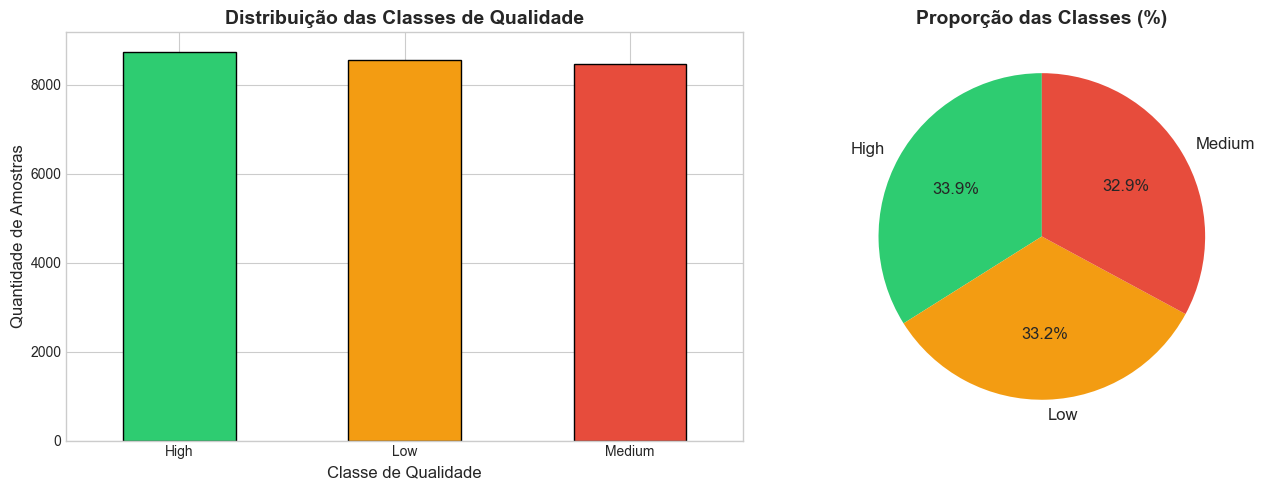

💡 Observe: as classes estão aproximadamente balanceadas? Isso é bom para o treinamento!


In [9]:
# ============================================================
# 4.2 — GRÁFICO DE DISTRIBUIÇÃO DAS CLASSES
# ============================================================
# Um gráfico de barras mostra visualmente se as classes estão balanceadas.
# Classes desbalanceadas podem fazer o modelo "viciar" na classe majoritária.

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico de barras com contagem
colors = ['#2ecc71', '#f39c12', '#e74c3c']  # Verde, Laranja, Vermelho
df[TARGET].value_counts().plot(kind='bar', ax=axes[0], color=colors, edgecolor='black')
axes[0].set_title('Distribuição das Classes de Qualidade', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Classe de Qualidade', fontsize=12)
axes[0].set_ylabel('Quantidade de Amostras', fontsize=12)
axes[0].tick_params(axis='x', rotation=0)

# Gráfico de pizza com proporções
df[TARGET].value_counts().plot(kind='pie', ax=axes[1], colors=colors,
                                autopct='%1.1f%%', startangle=90, fontsize=12)
axes[1].set_title('Proporção das Classes (%)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('')  # Remove o label do eixo y no gráfico de pizza

plt.tight_layout()
plt.savefig('distribuicao_classes.png', dpi=100, bbox_inches='tight')
plt.show()
print("💡 Observe: as classes estão aproximadamente balanceadas? Isso é bom para o treinamento!")

In [10]:
# ============================================================
# 4.3 — IDENTIFICAR FEATURES NUMÉRICAS vs CATEGÓRICAS
# ============================================================
# Features numéricas: números contínuos (ex: temperatura, peso)
# Features categóricas: categorias/texto (ex: tipo de tecido, tipo de acabamento)
# Essa distinção é importante porque cada tipo precisa de tratamento diferente.

# Separa colunas numéricas e categóricas automaticamente
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = df.select_dtypes(include=['object']).columns.tolist()

print(f"📐 Features NUMÉRICAS ({len(num_cols)}):")
for col in num_cols:
    print(f"   • {col}")

print(f"\n📝 Features CATEGÓRICAS ({len(cat_cols)}):")
for col in cat_cols:
    print(f"   • {col} → valores únicos: {df[col].nunique()}")

📐 Features NUMÉRICAS (14):
   • thread_count
   • gsm
   • tensile_strength
   • shrinkage_percent
   • color_fastness
   • fabric_thickness
   • defect_count
   • elongation_percent
   • moisture_absorption
   • batch_id
   • roll_number
   • inspection_time_minutes
   • machine_temperature
   • humidity_level

📝 Features CATEGÓRICAS (9):
   • fabric_type → valores únicos: 5
   • weave_type → valores únicos: 3
   • finish_type → valores únicos: 3
   • production_method → valores únicos: 2
   • warehouse_id → valores únicos: 3
   • operator_name → valores únicos: 5
   • inspection_shift → valores únicos: 3
   • inspection_notes → valores únicos: 5
   • fabric_quality → valores únicos: 3


In [11]:
# ============================================================
# 4.4 — ESTATÍSTICAS DESCRITIVAS
# ============================================================
# .describe() calcula: count, mean, std, min, 25%, 50% (mediana), 75%, max
# Isso dá uma visão rápida de como os dados numéricos se distribuem.

print("📊 Estatísticas Descritivas das Features Numéricas:")
df[num_cols].describe().round(2)

📊 Estatísticas Descritivas das Features Numéricas:


,thread_count,gsm,tensile_strength,shrinkage_percent,color_fastness,fabric_thickness,defect_count,elongation_percent,moisture_absorption,batch_id,roll_number,inspection_time_minutes,machine_temperature,humidity_level
count,24460.00,24465.00,24458.00,24467.00,25750.00,25750.00,25750.00,25750.00,25750.00,25750.00,25750.00,25750.00,25750.00,25750.00
mean,213.50,243.92,67.52,5.25,2.99,0.82,7.01,22.70,8.95,550820.27,2485.33,32.51,32.48,60.18
std,77.88,89.56,30.30,2.74,1.42,0.39,4.34,10.12,3.46,259917.81,1434.06,15.90,7.23,17.30
min,80.00,90.00,15.00,0.50,1.00,0.15,0.00,5.00,3.00,100028.00,1.00,5.00,20.00,30.00
25%,146.00,166.00,41.37,2.86,2.00,0.49,3.00,13.93,5.94,323703.75,1245.00,18.72,26.16,45.17
50%,213.00,244.00,67.69,5.27,3.00,0.83,7.00,22.87,8.93,550567.00,2467.00,32.51,32.43,60.45
75%,281.00,322.00,93.94,7.63,4.00,1.16,11.00,31.50,11.94,775292.50,3709.00,46.29,38.76,75.13
max,349.00,399.00,120.00,10.00,5.00,1.50,14.00,40.00,15.00,999982.00,4999.00,60.00,45.00,90.00


⚠️  Encontramos 7 colunas com valores nulos:

                   Nulos  % do Total
inspection_shift    1302        5.06
fabric_type         1292        5.02
tensile_strength    1292        5.02
thread_count        1290        5.01
weave_type          1287        5.00
gsm                 1285        4.99
shrinkage_percent   1283        4.98


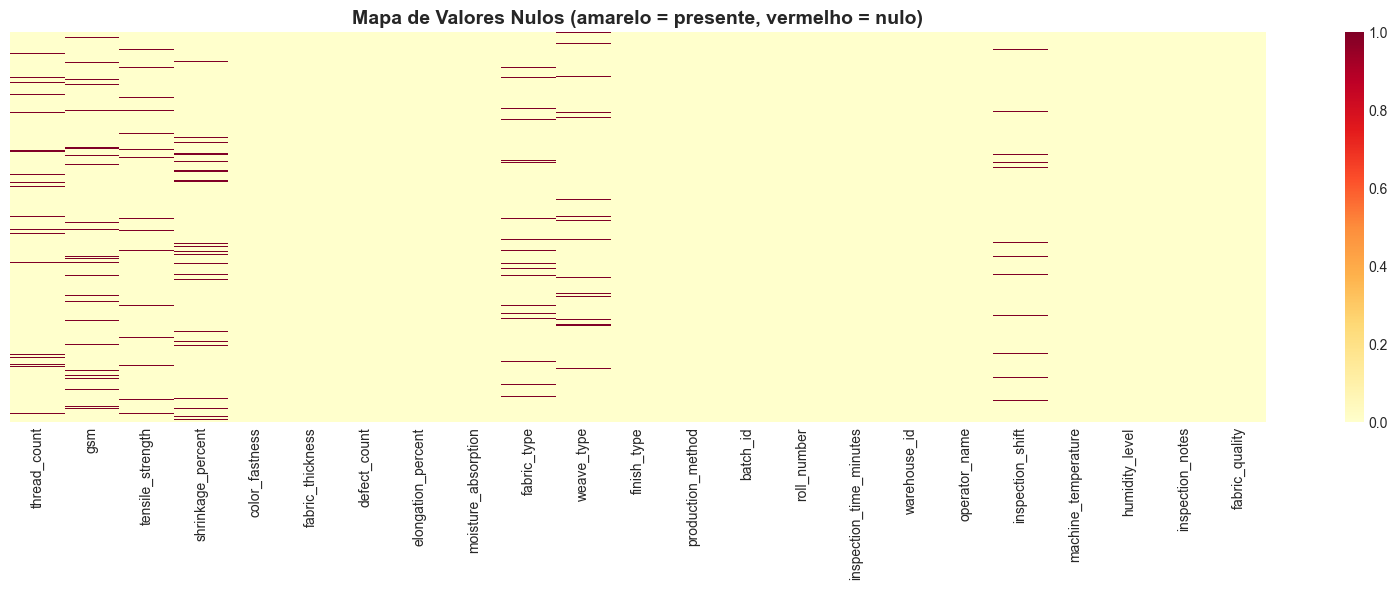


🔢 Total de valores nulos no dataset: 9,031
thread_count               5.01
gsm                        4.99
tensile_strength           5.02
shrinkage_percent          4.98
color_fastness             0.00
fabric_thickness           0.00
defect_count               0.00
elongation_percent         0.00
moisture_absorption        0.00
fabric_type                5.02
weave_type                 5.00
finish_type                0.00
production_method          0.00
batch_id                   0.00
roll_number                0.00
inspection_time_minutes    0.00
warehouse_id               0.00
operator_name              0.00
inspection_shift           5.06
machine_temperature        0.00
humidity_level             0.00
inspection_notes           0.00
fabric_quality             0.00
dtype: float64


In [14]:
# ============================================================
# 4.5 — VERIFICAÇÃO DE VALORES NULOS
# ============================================================
# Valores nulos (NaN) são dados faltantes. Modelos de ML não aceitam nulos,
# então precisamos identificá-los e tratá-los antes do treinamento.

nulos = df.isnull().sum()
nulos_pct = (df.isnull().sum() / len(df) * 100).round(2)

# Mostra apenas colunas com nulos
nulos_df = pd.DataFrame({'Nulos': nulos, '% do Total': nulos_pct})
nulos_com_dados = nulos_df[nulos_df['Nulos'] > 0].sort_values('Nulos', ascending=False)

if len(nulos_com_dados) > 0:
    print(f"⚠️  Encontramos {len(nulos_com_dados)} colunas com valores nulos:\n")
    print(nulos_com_dados)

    # Heatmap de nulos — cada ponto branco é um valor faltante
    plt.figure(figsize=(16, 6))
    sns.heatmap(df.isnull(), cbar=True, yticklabels=False, cmap='YlOrRd')
    plt.title('Mapa de Valores Nulos (amarelo = presente, vermelho = nulo)',
              fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print("✅ Nenhum valor nulo encontrado!")

print(f"\n🔢 Total de valores nulos no dataset: {df.isnull().sum().sum():,}")

In [13]:
# ============================================================
# 4.6 — VERIFICAÇÃO DE DUPLICATAS
# ============================================================
# Duplicatas são linhas idênticas. Elas podem distorcer o treinamento
# dando mais "peso" a certas amostras sem motivo.

n_duplicatas = df.duplicated().sum()
print(f"🔄 Linhas duplicadas encontradas: {n_duplicatas:,}")
print(f"   Isso representa {(n_duplicatas / len(df) * 100):.2f}% do dataset")

🔄 Linhas duplicadas encontradas: 750
   Isso representa 2.91% do dataset


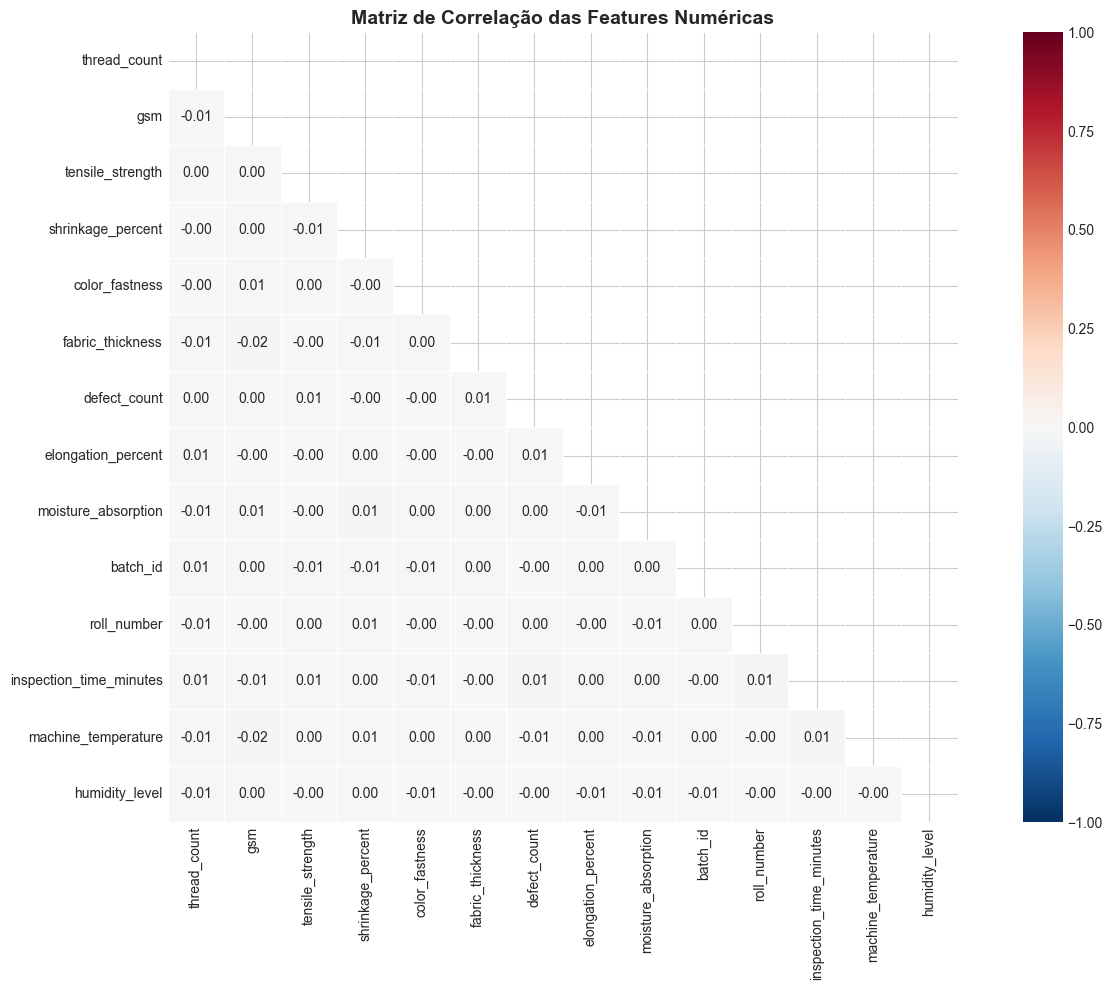

💡 Dica: features com correlação > 0.9 ou < -0.9 são quase duplicadas.


In [16]:
# ============================================================
# 4.7 — MATRIZ DE CORRELAÇÃO (apenas features numéricas)
# ============================================================
# A correlação mede o quão relacionadas são duas variáveis (-1 a +1).
#   +1 = quando uma sobe, a outra sobe junto (correlação positiva perfeita)
#    0 = sem relação linear
#   -1 = quando uma sobe, a outra desce (correlação negativa perfeita)
#
# Por que isso importa? Features muito correlacionadas entre si (ex: 0.95)
# são redundantes — podemos remover uma delas sem perder informação.

# Seleciona apenas features numéricas (exclui a coluna alvo se for numérica)
num_features = [col for col in num_cols if col != TARGET]

if len(num_features) > 1:
    plt.figure(figsize=(14, 10))
    corr_matrix = df[num_features].corr()

    # mask para mostrar apenas a metade inferior da matriz (evita repetição)
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

    sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
                cmap='RdBu_r', center=0, vmin=-1, vmax=1,
                square=True, linewidths=0.5)
    plt.title('Matriz de Correlação das Features Numéricas', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('correlacao_features.png', dpi=100, bbox_inches='tight')
    plt.show()

    print("💡 Dica: features com correlação > 0.9 ou < -0.9 são quase duplicadas.")
else:
    print("ℹ️  Poucas features numéricas para calcular correlação significativa.")

## 5️⃣ Tratamento de Valores Nulos e Duplicatas

Agora que sabemos os problemas dos nossos dados, vamos tratá-los:

### Estratégias de tratamento:
- **Duplicatas:** remover simplesmente (são repetições desnecessárias)
- **Nulos numéricos:** preencher com a **mediana** da coluna
  - *Por que mediana e não média?* A mediana é mais **robusta a outliers**. Se tivermos um valor discrepante (ex: uma medição errada de 9999), a média seria puxada para cima, mas a mediana não.
- **Nulos categóricos:** preencher com a **moda** (valor mais frequente)

> ⚠️ **Importante:** Nunca apague dados nulos sem pensar! Sempre entenda o contexto antes de decidir a estratégia.

In [20]:
# ============================================================
# 5.1 — REMOÇÃO DE DUPLICATAS
# ============================================================

shape_antes = df.shape[0]

# drop_duplicates() remove linhas que são cópias exatas de outras
df = df.drop_duplicates()

shape_depois = df.shape[0]
removidas = shape_antes - shape_depois

print(f"🔄 Remoção de duplicatas:")
print(f"   Antes:    {shape_antes:,} linhas")
print(f"   Depois:   {shape_depois:,} linhas")
print(f"   Removidas: {removidas:,} linhas ({(removidas/shape_antes*100):.2f}%)")

🔄 Remoção de duplicatas:
   Antes:    25,000 linhas
   Depois:   25,000 linhas
   Removidas: 0 linhas (0.00%)


In [21]:
# ============================================================
# 5.2 — TRATAMENTO DE VALORES NULOS
# ============================================================

# Atualiza listas de colunas numéricas e categóricas após remoção de duplicatas
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = df.select_dtypes(include=['object']).columns.tolist()

nulos_antes = df.isnull().sum().sum()
print(f"⚠️  Total de nulos ANTES do tratamento: {nulos_antes:,}\n")

# --- Preenche nulos NUMÉRICOS com a mediana ---
# A mediana é o valor do meio quando os dados são ordenados.
# Exemplo: [1, 2, 100] → mediana = 2, média = 34.3
# A mediana é mais robusta porque não é afetada pelo outlier (100).
for col in num_cols:
    n_nulos = df[col].isnull().sum()
    if n_nulos > 0:
        mediana = df[col].median()
        df[col] = df[col].fillna(mediana)
        print(f"   🔧 {col}: {n_nulos} nulos → preenchidos com mediana = {mediana:.2f}")

# --- Preenche nulos CATEGÓRICOS com a moda ---
# A moda é o valor que mais aparece na coluna.
for col in cat_cols:
    n_nulos = df[col].isnull().sum()
    if n_nulos > 0:
        moda = df[col].mode()[0]  # [0] pega o primeiro valor da moda
        df[col] = df[col].fillna(moda)
        print(f"   🔧 {col}: {n_nulos} nulos → preenchidos com moda = '{moda}'")

# --- Validação final ---
nulos_depois = df.isnull().sum().sum()
print(f"\n✅ Total de nulos DEPOIS do tratamento: {nulos_depois}")
assert nulos_depois == 0, "Ainda existem nulos! Verifique o tratamento."

⚠️  Total de nulos ANTES do tratamento: 0


✅ Total de nulos DEPOIS do tratamento: 0


## 6️⃣ Encoding de Variáveis Categóricas e Feature Selection

Os modelos de ML trabalham com **números**, não com texto. Precisamos converter variáveis categóricas (como "cotton", "silk", "polyester") em números.

### LabelEncoder
Converte cada categoria em um número inteiro:
- "cotton" → 0, "linen" → 1, "polyester" → 2, "silk" → 3, "wool" → 4

### Feature Selection (Seleção de Features)
Nem todas as colunas do dataset são úteis para o modelo. Colunas como IDs, nomes de operadores ou metadados de warehouse são **ruído** — elas confundem o modelo ao invés de ajudar.

> 🏭 **Analogia:** Imagine que ao inspecionar um tecido, você anota o nome do inspetor e a cor da caneta usada. Essas informações não afetam a qualidade do tecido!

In [22]:
# ============================================================
# 6.1 — IDENTIFICAR E REMOVER COLUNAS IRRELEVANTES (RUÍDO)
# ============================================================
# O dataset inclui propositalmente colunas que não tem poder preditivo:
# IDs, batch numbers, nomes de operadores, notas de inspeção, etc.
# Vamos identificá-las e removê-las.

print("🔍 Analisando colunas para identificar ruído...\n")

# Critérios para considerar uma coluna como ruído:
# 1. Muitos valores únicos (parece ser um ID)
# 2. Nome sugere metadado (contém 'id', 'batch', 'operator', 'note', 'warehouse')

colunas_para_remover = []
keywords_ruido = ['id', 'batch', 'roll', 'warehouse', 'operator', 'note',
                  'inspector', 'timestamp', 'date', 'shift']

for col in df.columns:
    col_lower = col.lower()

    # Verifica se o nome da coluna contém palavras-chave de ruído
    eh_ruido = any(kw in col_lower for kw in keywords_ruido)

    # Verifica se tem muitos valores únicos em relação ao total (possível ID)
    ratio_unicos = df[col].nunique() / len(df)

    if eh_ruido or (ratio_unicos > 0.5 and df[col].dtype == 'object' and col != TARGET):
        colunas_para_remover.append(col)
        motivo = "palavra-chave de metadado" if eh_ruido else f"alta cardinalidade ({df[col].nunique()} únicos)"
        print(f"   🗑️  '{col}' → REMOVER ({motivo})")

# Remove colunas de ruído
if colunas_para_remover:
    df = df.drop(columns=colunas_para_remover)
    print(f"\n✅ {len(colunas_para_remover)} colunas de ruído removidas!")
else:
    print("   Nenhuma coluna de ruído identificada.")

print(f"📊 Shape atual do dataset: {df.shape}")
print(f"   Colunas restantes: {list(df.columns)}")

🔍 Analisando colunas para identificar ruído...

   🗑️  'batch_id' → REMOVER (palavra-chave de metadado)
   🗑️  'roll_number' → REMOVER (palavra-chave de metadado)
   🗑️  'warehouse_id' → REMOVER (palavra-chave de metadado)
   🗑️  'operator_name' → REMOVER (palavra-chave de metadado)
   🗑️  'inspection_shift' → REMOVER (palavra-chave de metadado)
   🗑️  'humidity_level' → REMOVER (palavra-chave de metadado)
   🗑️  'inspection_notes' → REMOVER (palavra-chave de metadado)

✅ 7 colunas de ruído removidas!
📊 Shape atual do dataset: (25000, 16)
   Colunas restantes: ['thread_count', 'gsm', 'tensile_strength', 'shrinkage_percent', 'color_fastness', 'fabric_thickness', 'defect_count', 'elongation_percent', 'moisture_absorption', 'fabric_type', 'weave_type', 'finish_type', 'production_method', 'inspection_time_minutes', 'machine_temperature', 'fabric_quality']


In [23]:
# ============================================================
# 6.2 — ENCODING DAS VARIÁVEIS CATEGÓRICAS
# ============================================================
# LabelEncoder transforma cada categoria em um número inteiro.
# Exemplo: fabric_type: "cotton"→0, "linen"→1, "polyester"→2, "silk"→3, "wool"→4

# Atualiza lista de colunas categóricas (após remoção de ruído)
cat_cols_restantes = df.select_dtypes(include=['object']).columns.tolist()

# Remove a coluna alvo da lista (vamos encodar ela separadamente)
if TARGET in cat_cols_restantes:
    cat_cols_restantes.remove(TARGET)

# Dicionário para guardar os encoders (vamos precisar na hora de fazer predições)
encoders = {}

print("🔄 Encoding de variáveis categóricas:\n")
for col in cat_cols_restantes:
    le = LabelEncoder()

    # Mostra o mapeamento ANTES de aplicar
    valores_unicos = df[col].unique()
    df[col] = le.fit_transform(df[col])

    # Guarda o encoder para uso futuro
    encoders[col] = le

    # Mostra o mapeamento criado
    mapeamento = dict(zip(le.classes_, le.transform(le.classes_)))
    print(f"   ✅ '{col}': {mapeamento}")

# Encoding da variável alvo
le_target = LabelEncoder()
df[TARGET] = le_target.fit_transform(df[TARGET])
encoders[TARGET] = le_target

mapeamento_target = dict(zip(le_target.classes_, le_target.transform(le_target.classes_)))
print(f"\n   🎯 '{TARGET}' (alvo): {mapeamento_target}")
print(f"\n✅ Encoding completo! Todas as colunas agora são numéricas.")

🔄 Encoding de variáveis categóricas:

   ✅ 'fabric_type': {'cotton': np.int64(0), 'linen': np.int64(1), 'polyester': np.int64(2), 'silk': np.int64(3), 'wool': np.int64(4)}
   ✅ 'weave_type': {'plain': np.int64(0), 'satin': np.int64(1), 'twill': np.int64(2)}
   ✅ 'finish_type': {'dyed': np.int64(0), 'printed': np.int64(1), 'raw': np.int64(2)}
   ✅ 'production_method': {'handloom': np.int64(0), 'powerloom': np.int64(1)}

   🎯 'fabric_quality' (alvo): {'High': np.int64(0), 'Low': np.int64(1), 'Medium': np.int64(2)}

✅ Encoding completo! Todas as colunas agora são numéricas.


In [24]:
# ============================================================
# 6.3 — VERIFICAÇÃO FINAL DO DATAFRAME LIMPO
# ============================================================

print("📊 Dataset LIMPO e pronto para treinamento:")
print(f"   Shape: {df.shape}")
print(f"   Colunas: {list(df.columns)}")
print(f"   Tipos: todos numéricos? {all(df.dtypes != 'object')}")
print(f"   Nulos restantes: {df.isnull().sum().sum()}")
print(f"\n🔍 Primeiras linhas do dataset limpo:")
df.head()

📊 Dataset LIMPO e pronto para treinamento:
   Shape: (25000, 16)
   Colunas: ['thread_count', 'gsm', 'tensile_strength', 'shrinkage_percent', 'color_fastness', 'fabric_thickness', 'defect_count', 'elongation_percent', 'moisture_absorption', 'fabric_type', 'weave_type', 'finish_type', 'production_method', 'inspection_time_minutes', 'machine_temperature', 'fabric_quality']
   Tipos: todos numéricos? True
   Nulos restantes: 0

🔍 Primeiras linhas do dataset limpo:


,thread_count,gsm,tensile_strength,shrinkage_percent,color_fastness,fabric_thickness,defect_count,elongation_percent,moisture_absorption,fabric_type,weave_type,finish_type,production_method,inspection_time_minutes,machine_temperature,fabric_quality
0,166.0,383.0,67.772683,7.744704,1,0.891865,11,31.299228,12.855777,2,2,2,0,45.957289,28.148868,1
1,273.0,107.0,106.508682,1.191272,1,0.872380,4,8.092515,7.224689,2,1,0,0,33.035982,42.033282,0
2,274.0,352.0,97.100410,5.274223,3,1.231906,3,24.134907,12.276679,3,1,1,0,35.768493,35.450923,0
3,213.0,200.0,17.876660,4.001214,1,0.320100,12,18.334479,14.732114,1,2,1,1,38.349274,23.459327,1
4,115.0,348.0,62.746013,2.529863,2,0.903725,14,6.396909,11.692512,0,0,1,1,44.339097,33.873426,1


## 7️⃣ Divisão dos Dados: Treino e Teste

Agora vamos **dividir o dataset em dois conjuntos**:

| Conjunto | % dos Dados | Para que serve |
|---|---|---|
| **Treino** | 80% | O modelo **aprende** com esses dados |
| **Teste** | 20% | Avaliamos a performance **em dados nunca vistos** |

### Por que dividir?
Se avaliarmos o modelo nos mesmos dados que ele usou para aprender, seria como dar a prova com as respostas. O modelo teria nota alta, mas não saberia nada de verdade!

### Conceitos importantes:
- **`stratify=y`**: garante que a proporção das classes (Low/Medium/High) seja mantida tanto no treino quanto no teste
- **`StandardScaler`**: padroniza as features para terem média=0 e desvio=1. Isso é importante porque features com escalas diferentes (ex: RPM vai até 3000, mas percentual vai até 100) podem dominar o modelo
- **fit no treino, transform no teste**: o scaler aprende a escala apenas do treino para não "espiar" os dados de teste

In [25]:
# ============================================================
# DIVISÃO TREINO/TESTE + PADRONIZAÇÃO
# ============================================================

# --- Separar features (X) e target (y) ---
# X = todas as colunas EXCETO a coluna alvo
# y = apenas a coluna alvo (o que queremos prever)
X = df.drop(columns=[TARGET])
y = df[TARGET]

print(f"📦 Features (X): {X.shape} → {X.shape[1]} features")
print(f"🎯 Target  (y): {y.shape} → classes = {sorted(y.unique())}")

# --- Dividir em treino (80%) e teste (20%) ---
# random_state=42: garante que a divisão seja sempre igual (reprodutibilidade)
# stratify=y: mantém a proporção das classes em ambos os conjuntos
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,        # 20% para teste
    random_state=42,      # Semente para reprodutibilidade
    stratify=y            # Mantém proporção das classes
)

print(f"\n📊 Divisão realizada:")
print(f"   Treino: {X_train.shape[0]:,} amostras ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"   Teste:  {X_test.shape[0]:,} amostras ({X_test.shape[0]/len(X)*100:.0f}%)")

# Verifica se stratify funcionou
print(f"\n   Proporção das classes no TREINO:")
for cls in sorted(y_train.unique()):
    nome_cls = le_target.inverse_transform([cls])[0]
    pct = (y_train == cls).sum() / len(y_train) * 100
    print(f"      {nome_cls}: {pct:.1f}%")

📦 Features (X): (25000, 15) → 15 features
🎯 Target  (y): (25000,) → classes = [np.int64(0), np.int64(1), np.int64(2)]

📊 Divisão realizada:
   Treino: 20,000 amostras (80%)
   Teste:  5,000 amostras (20%)

   Proporção das classes no TREINO:
      High: 34.0%
      Low: 33.1%
      Medium: 33.0%


In [26]:
# ============================================================
# PADRONIZAÇÃO COM StandardScaler
# ============================================================
# O StandardScaler transforma cada feature para ter:
#   - Média = 0
#   - Desvio padrão = 1
#
# REGRA DE OURO: fit() apenas no treino, transform() em treino E teste.
# Se fizermos fit() no teste, estaríamos "espiando" dados que o modelo
# nunca deveria ter visto → vazamento de dados (data leakage)!

scaler = StandardScaler()

# fit_transform no TREINO: aprende a escala E transforma
X_train_scaled = scaler.fit_transform(X_train)

# transform no TESTE: usa a MESMA escala do treino (sem fit!)
X_test_scaled = scaler.transform(X_test)

# Mostra a diferença antes e depois
print("📏 Efeito da padronização (primeira feature como exemplo):")
print(f"   ANTES  → média: {X_train.iloc[:, 0].mean():.2f}, desvio: {X_train.iloc[:, 0].std():.2f}")
print(f"   DEPOIS → média: {X_train_scaled[:, 0].mean():.2f}, desvio: {X_train_scaled[:, 0].std():.2f}")
print("\n✅ Dados padronizados e prontos para treinamento!")

📏 Efeito da padronização (primeira feature como exemplo):
   ANTES  → média: 213.17, desvio: 76.00
   DEPOIS → média: 0.00, desvio: 1.00

✅ Dados padronizados e prontos para treinamento!


## 8️⃣ Treinamento do Modelo RandomForest com MLflow Tracking

Agora vem a parte principal: **treinar o modelo de Machine Learning!**

### RandomForestClassifier 🌳🌳🌳
O Random Forest é um modelo que cria **várias árvores de decisão** e combina as previsões delas por votação. É como pedir a opinião de 100 inspetores de qualidade — a maioria ganha!

### Hiperparâmetros que vamos usar:
| Parâmetro | Valor | O que faz |
|---|---|---|
| `n_estimators` | 100 | Número de árvores na floresta |
| `max_depth` | 15 | Profundidade máxima de cada árvore |
| `random_state` | 42 | Semente para reprodutibilidade |
| `n_jobs` | -1 | Usa todos os núcleos do processador |

### MLflow em ação:
Dentro do bloco `mlflow.start_run()`, tudo que registrarmos fica salvo automaticamente:
- `mlflow.log_param()` → registra um hiperparâmetro
- `mlflow.log_metric()` → registra uma métrica de avaliação
- `mlflow.log_artifact()` → registra um arquivo (gráfico, modelo, etc.)

In [27]:
# ============================================================
# TREINAMENTO DO RANDOMFOREST COM MLFLOW TRACKING
# ============================================================

# Nomes das classes para exibição nos gráficos
nomes_classes = le_target.classes_  # ['High', 'Low', 'Medium'] (ou similar)
feature_names = X.columns.tolist()

# Inicia um "run" no MLflow — tudo dentro deste bloco fica registrado
with mlflow.start_run(run_name="RandomForest_v1") as run:

    # ---- 1. DEFINIR HIPERPARÂMETROS ----
    params = {
        "n_estimators": 100,    # 100 árvores na floresta
        "max_depth": 15,        # Cada árvore pode ter no máximo 15 níveis
        "random_state": 42,     # Reprodutibilidade
        "n_jobs": -1,           # Usar todos os cores do CPU
        "class_weight": "balanced"  # Ajuste automático para classes desbalanceadas
    }

    # Registra cada parâmetro no MLflow
    for param_name, param_value in params.items():
        mlflow.log_param(param_name, param_value)

    # ---- REGISTRAR INFORMAÇÕES DO DATASET ----
    # Metadados básicos do dataset
    mlflow.log_param("dataset", "textile_fabric_quality")
    mlflow.log_param("dataset_source", "kaggle/devendrakushwah08/textile-fabric-quality-classification-dataset")
    mlflow.log_param("n_features", X_train_scaled.shape[1])
    mlflow.log_param("n_train_samples", X_train_scaled.shape[0])
    mlflow.log_param("n_test_samples", X_test_scaled.shape[0])
    mlflow.log_param("n_total_samples", len(df))
    mlflow.log_param("test_size", 0.2)
    mlflow.log_param("feature_names", ", ".join(feature_names))
    mlflow.log_param("target_column", TARGET)
    mlflow.log_param("n_classes", len(nomes_classes))
    mlflow.log_param("class_names", ", ".join(nomes_classes))

    # Distribuição das classes no treino
    for cls in sorted(y_train.unique()):
        nome_cls = le_target.inverse_transform([cls])[0]
        pct = (y_train == cls).sum() / len(y_train) * 100
        mlflow.log_param(f"train_class_{nome_cls}_pct", round(pct, 2))

    # Registra o dataset usando mlflow.data (rastreio formal do dataset)
    dataset_mlflow = mlflow.data.from_pandas(
        df, source="kaggle/devendrakushwah08/textile-fabric-quality-classification-dataset",
        name="textile_fabric_quality", targets=TARGET
    )
    mlflow.log_input(dataset_mlflow, context="training")

    print("🤖 Treinando RandomForest...")
    print(f"   Parâmetros: {params}")

    # ---- 2. CRIAR E TREINAR O MODELO ----
    # RandomForestClassifier cria várias árvores de decisão e combina por votação
    modelo = RandomForestClassifier(**params)

    # .fit() é onde o modelo APRENDE com os dados de treino
    modelo.fit(X_train_scaled, y_train)

    print("✅ Modelo treinado com sucesso!")

    # ---- 3. FAZER PREDIÇÕES NO CONJUNTO DE TESTE ----
    # O modelo nunca viu esses dados — é um teste justo!
    y_pred = modelo.predict(X_test_scaled)

    # ---- 4. CALCULAR MÉTRICAS ----
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='macro')  # 'macro' = média das classes

    # Registra métricas no MLflow
    mlflow.log_metric("accuracy", acc)
    mlflow.log_metric("f1_macro", f1)

    print(f"\n📊 Resultados:")
    print(f"   Accuracy: {acc:.4f} ({acc*100:.2f}%)")
    print(f"   F1-Score (macro): {f1:.4f}")

    # Guarda o run_id para referência futura
    run_id = run.info.run_id
    print(f"\n📝 MLflow Run ID: {run_id}")
    print(f"📦 Dataset registrado no MLflow com {len(df)} amostras e {len(feature_names)} features")

🤖 Treinando RandomForest...
   Parâmetros: {'n_estimators': 100, 'max_depth': 15, 'random_state': 42, 'n_jobs': -1, 'class_weight': 'balanced'}
✅ Modelo treinado com sucesso!

📊 Resultados:
   Accuracy: 0.8786 (87.86%)
   F1-Score (macro): 0.8790

📝 MLflow Run ID: e5e68bd0b1db4bd58d8dbc1ace22133d
📦 Dataset registrado no MLflow com 25000 amostras e 15 features


## 9️⃣ Avaliação do Modelo: Métricas e Matriz de Confusão

Vamos analisar em detalhes **quão bom** é o nosso modelo.

### Métricas que vamos usar:

| Métrica | O que mede | Quando usar |
|---|---|---|
| **Accuracy** | % de acertos total | Boa para classes balanceadas |
| **Precision** | Dos que o modelo disse ser X, quantos realmente são X? | Quando falso positivo é grave |
| **Recall** | Dos que realmente são X, quantos o modelo encontrou? | Quando falso negativo é grave |
| **F1-Score** | Média harmônica de precision e recall | Equilíbrio entre precision e recall |

### Matriz de Confusão
Mostra exatamente onde o modelo **acerta e erra**. Cada célula (i,j) indica quantas amostras da classe i foram classificadas como classe j.

- **Diagonal principal** (verde) = acertos ✅
- **Fora da diagonal** (vermelho) = erros ❌

In [29]:
# ============================================================
# 9.1 — CLASSIFICATION REPORT (RELATÓRIO COMPLETO)
# ============================================================
# O classification_report mostra precision, recall e F1 para CADA classe.
# Isso é muito mais informativo que apenas a accuracy geral.

print("📋 Classification Report:")
print("=" * 65)
print(classification_report(y_test, y_pred, target_names=nomes_classes))
print("=" * 65)
print("\n💡 Leitura dos resultados:")
print("   • Precision alta = poucas 'falsas alarmes' naquela classe")
print("   • Recall alto = o modelo encontra quase todos os exemplos daquela classe")
print("   • F1-Score = equilíbrio entre precision e recall")

📋 Classification Report:
              precision    recall  f1-score   support

        High       0.92      0.89      0.91      1697
         Low       0.92      0.89      0.90      1655
      Medium       0.81      0.85      0.83      1648

    accuracy                           0.88      5000
   macro avg       0.88      0.88      0.88      5000
weighted avg       0.88      0.88      0.88      5000


💡 Leitura dos resultados:
   • Precision alta = poucas 'falsas alarmes' naquela classe
   • Recall alto = o modelo encontra quase todos os exemplos daquela classe
   • F1-Score = equilíbrio entre precision e recall


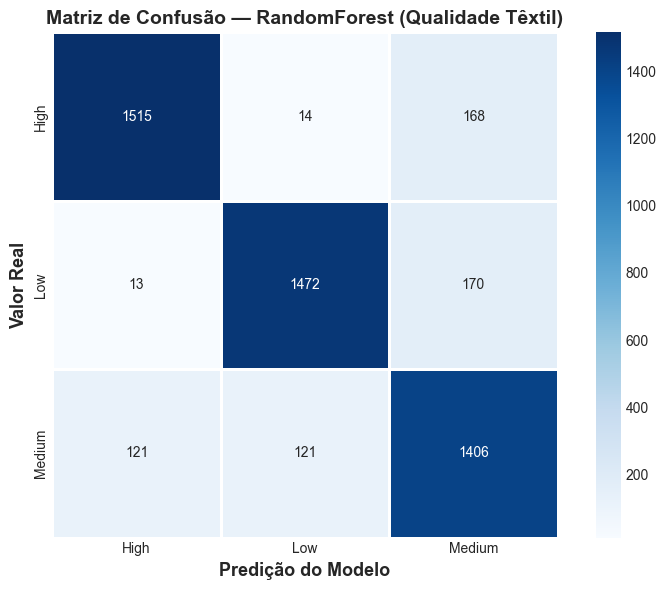

💡 A diagonal principal (de cima-esquerda para baixo-direita) mostra os ACERTOS.
   Valores fora da diagonal são ERROS — o modelo confundiu uma classe com outra.


In [30]:
# ============================================================
# 9.2 — MATRIZ DE CONFUSÃO (VISUALIZAÇÃO)
# ============================================================
# A matriz mostra onde o modelo acerta (diagonal) e onde erra.

cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=nomes_classes,
            yticklabels=nomes_classes,
            square=True, linewidths=1, linecolor='white')

ax.set_xlabel('Predição do Modelo', fontsize=13, fontweight='bold')
ax.set_ylabel('Valor Real', fontsize=13, fontweight='bold')
ax.set_title('Matriz de Confusão — RandomForest (Qualidade Têxtil)',
             fontsize=14, fontweight='bold')

plt.tight_layout()

# Salva a imagem para registrar como artefato no MLflow
cm_path = 'confusion_matrix_rf_v1.png'
plt.savefig(cm_path, dpi=150, bbox_inches='tight')
plt.show()

print("💡 A diagonal principal (de cima-esquerda para baixo-direita) mostra os ACERTOS.")
print("   Valores fora da diagonal são ERROS — o modelo confundiu uma classe com outra.")

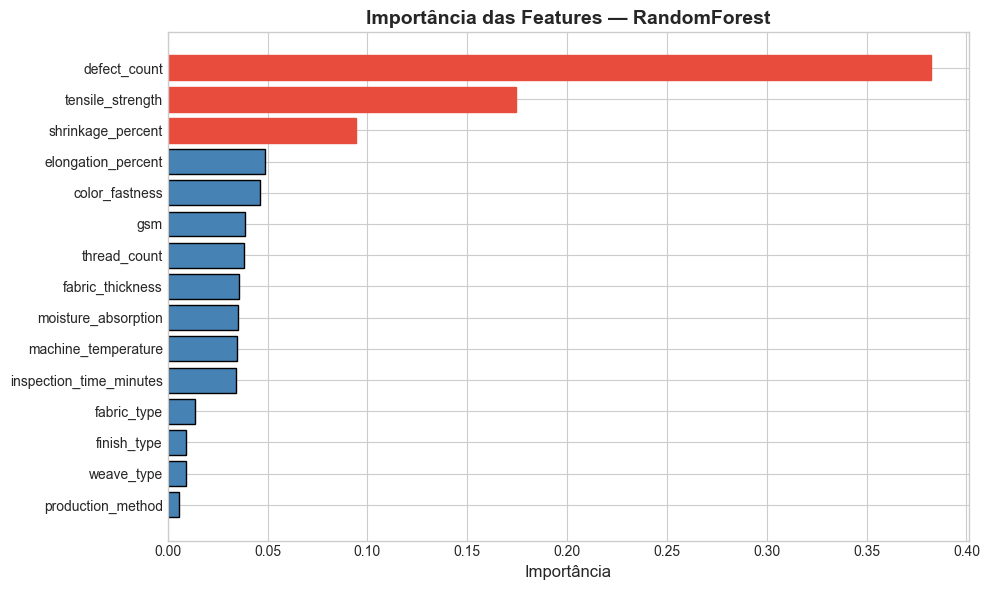

🔴 As barras em VERMELHO são as 3 features mais importantes para o modelo.
💡 Na prática, isso indica quais variáveis do processo industrial mais afetam a qualidade.


In [ ]:
# ============================================================
# 9.3 — FEATURE IMPORTANCES (IMPORTÂNCIA DAS FEATURES)
# ============================================================
# O RandomForest calcula automaticamente quais features mais contribuíram
# para as decisões do modelo. Isso é MUITO útil na indústria para entender
# quais variáveis do processo mais impactam a qualidade do tecido.

importances = modelo.feature_importances_

# Cria DataFrame ordenado por importância
feat_imp_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=True)  # ascending=True para barh

fig, ax = plt.subplots(figsize=(10, max(6, len(feature_names) * 0.4)))
bars = ax.barh(feat_imp_df['Feature'], feat_imp_df['Importance'], color='steelblue', edgecolor='black')

# Destaca as 3 features mais importantes com cor diferente
top3_threshold = feat_imp_df['Importance'].nlargest(3).min()
for bar, imp in zip(bars, feat_imp_df['Importance']):
    if imp >= top3_threshold:
        bar.set_color('#e74c3c')  # Vermelho para as top 3

ax.set_xlabel('Importância', fontsize=12)
ax.set_title('Importância das Features — RandomForest', fontsize=14, fontweight='bold')
plt.tight_layout()

# Salva o gráfico
fi_path = 'feature_importances_rf_v2.png'
plt.savefig(fi_path, dpi=150, bbox_inches='tight')
plt.show()

print("🔴 As barras em VERMELHO são as 3 features mais importantes para o modelo.")
print("💡 Na prática, isso indica quais variáveis do processo industrial mais afetam a qualidade.")

In [33]:
# ============================================================
# 9.4 — REGISTRAR ARTEFATOS NO MLFLOW
# ============================================================
# Artefatos são arquivos que queremos guardar junto com o experimento:
# gráficos, datasets, modelos, etc.

# --- Salva o dataset limpo como CSV para rastreabilidade ---
dataset_csv_path = 'dataset_limpo.csv'
df.to_csv(dataset_csv_path, index=False)

# --- Gera um resumo textual do dataset ---
dataset_info_path = 'dataset_info.txt'
with open(dataset_info_path, 'w', encoding='utf-8') as f:
    f.write("=" * 60 + "\n")
    f.write("RESUMO DO DATASET — Textile Fabric Quality Classification\n")
    f.write("=" * 60 + "\n\n")
    f.write(f"Fonte: Kaggle (devendrakushwah08/textile-fabric-quality-classification-dataset)\n")
    f.write(f"Total de amostras (após limpeza): {len(df):,}\n")
    f.write(f"Total de features: {len(feature_names)}\n")
    f.write(f"Coluna alvo: {TARGET}\n")
    f.write(f"Classes: {list(nomes_classes)}\n\n")
    f.write(f"--- Distribuição das classes ---\n")
    for cls in sorted(df[TARGET].unique()):
        nome_cls = le_target.inverse_transform([cls])[0]
        count = (df[TARGET] == cls).sum()
        pct = count / len(df) * 100
        f.write(f"  {nome_cls}: {count:,} ({pct:.1f}%)\n")
    f.write(f"\n--- Features utilizadas ---\n")
    for i, feat in enumerate(feature_names, 1):
        f.write(f"  {i:2d}. {feat}\n")
    f.write(f"\n--- Estatísticas descritivas ---\n")
    f.write(df.describe().round(2).to_string())
    f.write("\n")

# Reabre o run para registrar artefatos adicionais
with mlflow.start_run(run_id=run_id):
    # Registra os gráficos como artefatos
    if os.path.exists(cm_path):
        mlflow.log_artifact(cm_path, "graficos")
    if os.path.exists(fi_path):
        mlflow.log_artifact(fi_path, "graficos")
    if os.path.exists('distribuicao_classes.png'):
        mlflow.log_artifact('distribuicao_classes.png', "graficos")
    if os.path.exists('correlacao_features.png'):
        mlflow.log_artifact('correlacao_features.png', "graficos")

    # Registra os arquivos do dataset como artefatos
    mlflow.log_artifact(dataset_csv_path, "dataset")
    mlflow.log_artifact(dataset_info_path, "dataset")

    # Registra o modelo no MLflow (formato sklearn)
    mlflow.sklearn.log_model(modelo, "modelo_random_forest")

    print("✅ Artefatos registrados no MLflow:")
    print("   📊 confusion_matrix_rf_v1.png")
    print("   📊 feature_importances_rf_v1.png")
    print("   📄 dataset_limpo.csv")
    print("   📄 dataset_info.txt")
    print("   🤖 modelo_random_forest")
    print(f"\n🔗 Para visualizar: execute 'mlflow ui' no terminal e acesse http://localhost:5000")

2026/04/15 21:26:59 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/15 21:26:59 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


✅ Artefatos registrados no MLflow:
   📊 confusion_matrix_rf_v1.png
   📊 feature_importances_rf_v1.png
   📄 dataset_limpo.csv
   📄 dataset_info.txt
   🤖 modelo_random_forest

🔗 Para visualizar: execute 'mlflow ui' no terminal e acesse http://localhost:5000


## 🔟 Exportação do Modelo Versionado

Além de salvar no MLflow, vamos exportar o modelo em um formato que pode ser reutilizado em outras aulas e em produção.

### Convenção de nomenclatura:
```
modelos/aula01/rf_qualidade_textil_v1.joblib
                │    │              │
                │    │              └── versão
                │    └── problema/dataset
                └── algoritmo (rf = RandomForest)
```

Esta convenção facilita identificar cada modelo entre os vários que treinaremos ao longo do curso:
- **Aula 01:** `rf_qualidade_textil_v1.joblib`
- **Aula 02:** `xgb_qualidade_textil_v1.joblib`
- **Aula 03:** `ridge_producao_textil_v1.joblib`
- **Etc.**

In [ ]:
# ============================================================
# EXPORTAÇÃO DO MODELO E SCALER
# ============================================================

# Caminho padrão para modelos (relativo à raiz do projeto)
MODELOS_DIR = os.path.join("..", "modelos", "aula01")

# Cria o diretório se não existir
os.makedirs(MODELOS_DIR, exist_ok=True)

# --- Salva o modelo treinado ---
# joblib é mais eficiente que pickle para objetos com arrays numpy grandes
modelo_path = os.path.join(MODELOS_DIR, "rf_qualidade_textil_v1.joblib")
joblib.dump(modelo, modelo_path)

# --- Salva o scaler (necessário para pré-processar novos dados) ---
scaler_path = os.path.join(MODELOS_DIR, "scaler_qualidade_textil_v1.joblib")
joblib.dump(scaler, scaler_path)

# --- Salva os encoders (necessários para converter categorias) ---
encoders_path = os.path.join(MODELOS_DIR, "encoders_qualidade_textil_v1.joblib")
joblib.dump(encoders, encoders_path)

# --- Salva a lista de features (ordem importa!) ---
features_path = os.path.join(MODELOS_DIR, "features_qualidade_textil_v1.joblib")
joblib.dump(feature_names, features_path)

print("💾 Artefatos exportados:")
print(f"   🤖 Modelo:   {modelo_path}")
print(f"   📏 Scaler:   {scaler_path}")
print(f"   🔤 Encoders: {encoders_path}")
print(f"   📋 Features: {features_path}")

# Verifica tamanho dos arquivos
for path in [modelo_path, scaler_path, encoders_path, features_path]:
    size_kb = os.path.getsize(path) / 1024
    print(f"   📦 {os.path.basename(path)}: {size_kb:.1f} KB")

💾 Artefatos exportados:
   🤖 Modelo:   ..\modelos\aula01\rf_qualidade_textil_v1.joblib
   📏 Scaler:   ..\modelos\aula01\scaler_qualidade_textil_v1.joblib
   🔤 Encoders: ..\modelos\aula01\encoders_qualidade_textil_v1.joblib
   📋 Features: ..\modelos\aula01\features_qualidade_textil_v1.joblib
   📦 rf_qualidade_textil_v1.joblib: 41212.7 KB
   📦 scaler_qualidade_textil_v1.joblib: 1.4 KB
   📦 encoders_qualidade_textil_v1.joblib: 1.5 KB
   📦 features_qualidade_textil_v1.joblib: 0.3 KB


In [35]:
# ============================================================
# TESTE: CARREGAR O MODELO E FAZER UMA PREDIÇÃO
# ============================================================
# Vamos simular o que aconteceria em produção: carregar o modelo salvo
# e fazer uma predição com dados novos.

print("🔄 Testando carregamento do modelo salvo...\n")

# Carrega o modelo e o scaler do disco
modelo_carregado = joblib.load(modelo_path)
scaler_carregado = joblib.load(scaler_path)

# Pega uma amostra do conjunto de teste para simular dados novos
amostra = X_test.iloc[[0]]  # Primeira amostra do teste
valor_real = y_test.iloc[0]

print(f"📥 Dados de entrada (amostra de teste):")
print(f"   {amostra.values[0][:5]}...  (mostrando 5 primeiros valores)")

# Aplica o scaler e faz a predição
amostra_scaled = scaler_carregado.transform(amostra)
predicao = modelo_carregado.predict(amostra_scaled)[0]

# Converte de volta para o nome da classe
classe_predita = le_target.inverse_transform([predicao])[0]
classe_real = le_target.inverse_transform([valor_real])[0]

print(f"\n🎯 Resultado:")
print(f"   Predição: {classe_predita}")
print(f"   Real:     {classe_real}")
print(f"   Correto?  {'✅ SIM!' if predicao == valor_real else '❌ NÃO'}")

print("\n✅ Modelo exportado e validado com sucesso! Pronto para uso futuro.")

🔄 Testando carregamento do modelo salvo...

📥 Dados de entrada (amostra de teste):
   [216.         311.          67.77268261   4.85722994   1.        ]...  (mostrando 5 primeiros valores)

🎯 Resultado:
   Predição: Low
   Real:     Low
   Correto?  ✅ SIM!

✅ Modelo exportado e validado com sucesso! Pronto para uso futuro.


---

## 📝 Atividade Complementar (Tempo estimado: 1h)

### Objetivo
Praticar o ciclo completo de **experimentação com MLflow** treinando modelos com diferentes configurações e comparando-os.

### Tarefas:

**Tarefa 1 — Modificar hiperparâmetros do RandomForest**
- Treine um **novo** RandomForest com `n_estimators=200` e `max_depth=20`
- Registre como um novo run no MLflow chamado `"RandomForest_v2"`
- Compare accuracy e F1-score com o modelo original

**Tarefa 2 — Treinar um DecisionTreeClassifier**
- Importe `DecisionTreeClassifier` do sklearn
- Treine com `max_depth=10` e `random_state=42`
- Registre no MLflow como `"DecisionTree_v1"`

**Tarefa 3 — Comparar os 3 modelos**
- Execute `mlflow ui` no terminal (fora do notebook)
- Acesse `http://localhost:5000` no navegador
- Compare os 3 runs lado a lado
- Responda: **qual modelo teve melhor F1-score? Por quê?**

> 💡 **Dica:** Use as células abaixo como guia. Substitua os comentários `# SEU CÓDIGO AQUI` pelo código apropriado.

In [ ]:
# ============================================================
# TAREFA 1 — RandomForest com novos hiperparâmetros
# ============================================================

# Nomes das classes para exibição nos gráficos
nomes_classes = le_target.classes_  # ['High', 'Low', 'Medium'] (ou similar)
feature_names = X.columns.tolist()

# Inicia um "run" no MLflow — tudo dentro deste bloco fica registrado
with mlflow.start_run(run_name="RandomForest_v2") as run:

    # ---- 1. DEFINIR HIPERPARÂMETROS ----
    params = {
        "n_estimators": 200,    # 200 árvores na floresta
        "max_depth": 20,        # Cada árvore pode ter no máximo 20 níveis
        "random_state": 42,     # Reprodutibilidade
        "n_jobs": -1,           # Usar todos os cores do CPU
        "class_weight": "balanced"  # Ajuste automático para classes desbalanceadas
    }

    # Registra cada parâmetro no MLflow
    for param_name, param_value in params.items():
        mlflow.log_param(param_name, param_value)

    # ---- REGISTRAR INFORMAÇÕES DO DATASET ----
    # Metadados básicos do dataset
    mlflow.log_param("dataset", "textile_fabric_quality")
    mlflow.log_param("dataset_source", "kaggle/devendrakushwah08/textile-fabric-quality-classification-dataset")
    mlflow.log_param("n_features", X_train_scaled.shape[1])
    mlflow.log_param("n_train_samples", X_train_scaled.shape[0])
    mlflow.log_param("n_test_samples", X_test_scaled.shape[0])
    mlflow.log_param("n_total_samples", len(df))
    mlflow.log_param("test_size", 0.2)
    mlflow.log_param("feature_names", ", ".join(feature_names))
    mlflow.log_param("target_column", TARGET)
    mlflow.log_param("n_classes", len(nomes_classes))
    mlflow.log_param("class_names", ", ".join(nomes_classes))

    # Distribuição das classes no treino
    for cls in sorted(y_train.unique()):
        nome_cls = le_target.inverse_transform([cls])[0]
        pct = (y_train == cls).sum() / len(y_train) * 100
        mlflow.log_param(f"train_class_{nome_cls}_pct", round(pct, 2))

    # Registra o dataset usando mlflow.data (rastreio formal do dataset)
    dataset_mlflow = mlflow.data.from_pandas(
        df, source="kaggle/devendrakushwah08/textile-fabric-quality-classification-dataset",
        name="textile_fabric_quality", targets=TARGET
    )
    mlflow.log_input(dataset_mlflow, context="training")

    print("🤖 Treinando RandomForest...")
    print(f"   Parâmetros: {params}")

    # ---- 2. CRIAR E TREINAR O MODELO ----
    # RandomForestClassifier cria várias árvores de decisão e combina por votação
    modelo = RandomForestClassifier(**params)

    # .fit() é onde o modelo APRENDE com os dados de treino
    modelo.fit(X_train_scaled, y_train)

    print("✅ Modelo treinado com sucesso!")

    # ---- 3. FAZER PREDIÇÕES NO CONJUNTO DE TESTE ----
    # O modelo nunca viu esses dados — é um teste justo!
    y_pred = modelo.predict(X_test_scaled)

    # ---- 4. CALCULAR MÉTRICAS ----
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='macro')  # 'macro' = média das classes

    # Registra métricas no MLflow
    mlflow.log_metric("accuracy", acc)
    mlflow.log_metric("f1_macro", f1)

    print(f"\n📊 Resultados:")
    print(f"   Accuracy: {acc:.4f} ({acc*100:.2f}%)")
    print(f"   F1-Score (macro): {f1:.4f}")

    # Guarda o run_id para referência futura
    run_id = run.info.run_id
    print(f"\n📝 MLflow Run ID: {run_id}")
    print(f"📦 Dataset registrado no MLflow com {len(df)} amostras e {len(feature_names)} features")

    

🤖 Treinando RandomForest...
   Parâmetros: {'n_estimators': 200, 'max_depth': 20, 'random_state': 42, 'n_jobs': -1, 'class_weight': 'balanced'}
✅ Modelo treinado com sucesso!

📊 Resultados:
   Accuracy: 0.8824 (88.24%)
   F1-Score (macro): 0.8827

📝 MLflow Run ID: a2719ae165874d93942bc081c3e11128
📦 Dataset registrado no MLflow com 25000 amostras e 15 features


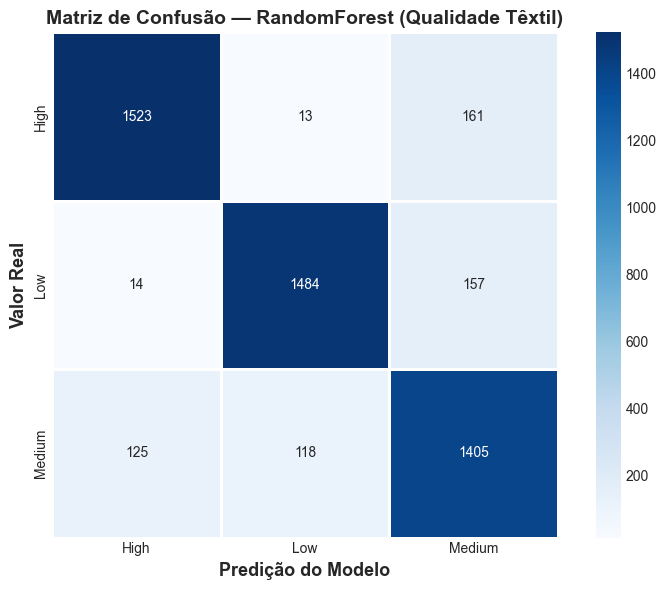

💡 A diagonal principal (de cima-esquerda para baixo-direita) mostra os ACERTOS.
   Valores fora da diagonal são ERROS — o modelo confundiu uma classe com outra.


In [38]:
# ============================================================
# 9.2 — MATRIZ DE CONFUSÃO (VISUALIZAÇÃO)
# ============================================================
# A matriz mostra onde o modelo acerta (diagonal) e onde erra.

cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=nomes_classes,
            yticklabels=nomes_classes,
            square=True, linewidths=1, linecolor='white')

ax.set_xlabel('Predição do Modelo', fontsize=13, fontweight='bold')
ax.set_ylabel('Valor Real', fontsize=13, fontweight='bold')
ax.set_title('Matriz de Confusão — RandomForest (Qualidade Têxtil)',
             fontsize=14, fontweight='bold')

plt.tight_layout()

# Salva a imagem para registrar como artefato no MLflow
cm_path = 'confusion_matrix_rf_v2.png'
plt.savefig(cm_path, dpi=150, bbox_inches='tight')
plt.show()

print("💡 A diagonal principal (de cima-esquerda para baixo-direita) mostra os ACERTOS.")
print("   Valores fora da diagonal são ERROS — o modelo confundiu uma classe com outra.")

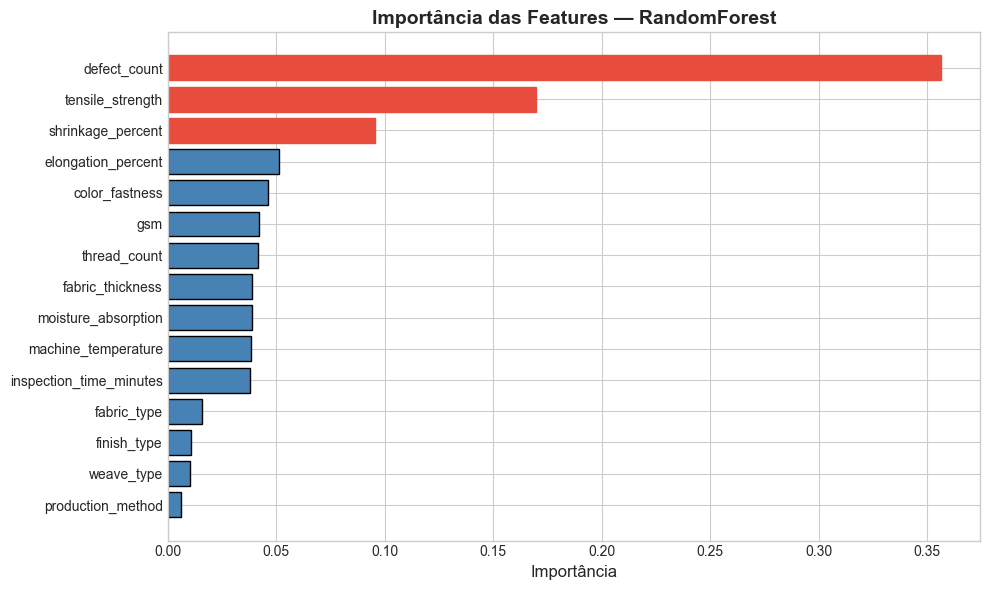

🔴 As barras em VERMELHO são as 3 features mais importantes para o modelo.
💡 Na prática, isso indica quais variáveis do processo industrial mais afetam a qualidade.


In [39]:
# ============================================================
# 9.3 — FEATURE IMPORTANCES (IMPORTÂNCIA DAS FEATURES)
# ============================================================
# O RandomForest calcula automaticamente quais features mais contribuíram
# para as decisões do modelo. Isso é MUITO útil na indústria para entender
# quais variáveis do processo mais impactam a qualidade do tecido.

importances = modelo.feature_importances_

# Cria DataFrame ordenado por importância
feat_imp_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=True)  # ascending=True para barh

fig, ax = plt.subplots(figsize=(10, max(6, len(feature_names) * 0.4)))
bars = ax.barh(feat_imp_df['Feature'], feat_imp_df['Importance'], color='steelblue', edgecolor='black')

# Destaca as 3 features mais importantes com cor diferente
top3_threshold = feat_imp_df['Importance'].nlargest(3).min()
for bar, imp in zip(bars, feat_imp_df['Importance']):
    if imp >= top3_threshold:
        bar.set_color('#e74c3c')  # Vermelho para as top 3

ax.set_xlabel('Importância', fontsize=12)
ax.set_title('Importância das Features — RandomForest', fontsize=14, fontweight='bold')
plt.tight_layout()

# Salva o gráfico
fi_path = 'feature_importances_rf_v2.png'
plt.savefig(fi_path, dpi=150, bbox_inches='tight')
plt.show()

print("🔴 As barras em VERMELHO são as 3 features mais importantes para o modelo.")
print("💡 Na prática, isso indica quais variáveis do processo industrial mais afetam a qualidade.")

In [40]:
# ============================================================
# 9.4 — REGISTRAR ARTEFATOS NO MLFLOW
# ============================================================
# Artefatos são arquivos que queremos guardar junto com o experimento:
# gráficos, datasets, modelos, etc.

# --- Salva o dataset limpo como CSV para rastreabilidade ---
dataset_csv_path = 'dataset_limpo_v2.csv'
df.to_csv(dataset_csv_path, index=False)

# --- Gera um resumo textual do dataset ---
dataset_info_path = 'dataset_info_v2.txt'
with open(dataset_info_path, 'w', encoding='utf-8') as f:
    f.write("=" * 60 + "\n")
    f.write("RESUMO DO DATASET — Textile Fabric Quality Classification\n")
    f.write("=" * 60 + "\n\n")
    f.write(f"Fonte: Kaggle (devendrakushwah08/textile-fabric-quality-classification-dataset)\n")
    f.write(f"Total de amostras (após limpeza): {len(df):,}\n")
    f.write(f"Total de features: {len(feature_names)}\n")
    f.write(f"Coluna alvo: {TARGET}\n")
    f.write(f"Classes: {list(nomes_classes)}\n\n")
    f.write(f"--- Distribuição das classes ---\n")
    for cls in sorted(df[TARGET].unique()):
        nome_cls = le_target.inverse_transform([cls])[0]
        count = (df[TARGET] == cls).sum()
        pct = count / len(df) * 100
        f.write(f"  {nome_cls}: {count:,} ({pct:.1f}%)\n")
    f.write(f"\n--- Features utilizadas ---\n")
    for i, feat in enumerate(feature_names, 1):
        f.write(f"  {i:2d}. {feat}\n")
    f.write(f"\n--- Estatísticas descritivas ---\n")
    f.write(df.describe().round(2).to_string())
    f.write("\n")

# Reabre o run para registrar artefatos adicionais
with mlflow.start_run(run_id=run_id):
    # Registra os gráficos como artefatos
    if os.path.exists(cm_path):
        mlflow.log_artifact(cm_path, "graficos")
    if os.path.exists(fi_path):
        mlflow.log_artifact(fi_path, "graficos")
    if os.path.exists('distribuicao_classes.png'):
        mlflow.log_artifact('distribuicao_classes.png', "graficos")
    if os.path.exists('correlacao_features.png'):
        mlflow.log_artifact('correlacao_features.png', "graficos")

    # Registra os arquivos do dataset como artefatos
    mlflow.log_artifact(dataset_csv_path, "dataset")
    mlflow.log_artifact(dataset_info_path, "dataset")

    # Registra o modelo no MLflow (formato sklearn)
    mlflow.sklearn.log_model(modelo, "modelo_random_forest")

    print("✅ Artefatos registrados no MLflow:")
    print("   📊 confusion_matrix_rf_v2.png")
    print("   📊 feature_importances_rf_v2.png")
    print("   📄 dataset_limpo_v2.csv")
    print("   📄 dataset_info_v2.txt")
    print("   🤖 modelo_random_forest")
    print(f"\n🔗 Para visualizar: execute 'mlflow ui' no terminal e acesse http://localhost:5000")

2026/04/15 21:44:20 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/15 21:44:20 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


✅ Artefatos registrados no MLflow:
   📊 confusion_matrix_rf_v2.png
   📊 feature_importances_rf_v2.png
   📄 dataset_limpo_v2.csv
   📄 dataset_info_v2.txt
   🤖 modelo_random_forest

🔗 Para visualizar: execute 'mlflow ui' no terminal e acesse http://localhost:5000


In [41]:
# ============================================================
# EXPORTAÇÃO DO MODELO E SCALER
# ============================================================

# Caminho padrão para modelos (relativo à raiz do projeto)
MODELOS_DIR = os.path.join("..", "modelos", "aula01")

# Cria o diretório se não existir
os.makedirs(MODELOS_DIR, exist_ok=True)

# --- Salva o modelo treinado ---
# joblib é mais eficiente que pickle para objetos com arrays numpy grandes
modelo_path = os.path.join(MODELOS_DIR, "rf_qualidade_textil_v2.joblib")
joblib.dump(modelo, modelo_path)

# --- Salva o scaler (necessário para pré-processar novos dados) ---
scaler_path = os.path.join(MODELOS_DIR, "scaler_qualidade_textil_v2.joblib")
joblib.dump(scaler, scaler_path)

# --- Salva os encoders (necessários para converter categorias) ---
encoders_path = os.path.join(MODELOS_DIR, "encoders_qualidade_textil_v2.joblib")
joblib.dump(encoders, encoders_path)

# --- Salva a lista de features (ordem importa!) ---
features_path = os.path.join(MODELOS_DIR, "features_qualidade_textil_v2.joblib")
joblib.dump(feature_names, features_path)

print("💾 Artefatos exportados:")
print(f"   🤖 Modelo:   {modelo_path}")
print(f"   📏 Scaler:   {scaler_path}")
print(f"   🔤 Encoders: {encoders_path}")
print(f"   📋 Features: {features_path}")

# Verifica tamanho dos arquivos
for path in [modelo_path, scaler_path, encoders_path, features_path]:
    size_kb = os.path.getsize(path) / 1024
    print(f"   📦 {os.path.basename(path)}: {size_kb:.1f} KB")

💾 Artefatos exportados:
   🤖 Modelo:   ..\modelos\aula01\rf_qualidade_textil_v2.joblib
   📏 Scaler:   ..\modelos\aula01\scaler_qualidade_textil_v2.joblib
   🔤 Encoders: ..\modelos\aula01\encoders_qualidade_textil_v2.joblib
   📋 Features: ..\modelos\aula01\features_qualidade_textil_v2.joblib
   📦 rf_qualidade_textil_v2.joblib: 107526.0 KB
   📦 scaler_qualidade_textil_v2.joblib: 1.4 KB
   📦 encoders_qualidade_textil_v2.joblib: 1.5 KB
   📦 features_qualidade_textil_v2.joblib: 0.3 KB


In [ ]:
# ============================================================
# TAREFA 2 — DecisionTreeClassifier
# ============================================================
# Dica: importe DecisionTreeClassifier e siga a mesma estrutura.

from sklearn.tree import DecisionTreeClassifier

📊 DecisionTree v1 — Accuracy: 0.8220 | F1: 0.8224


In [ ]:
# ============================================================
# TAREFA 3 — COMPARAÇÃO DOS MODELOS
# ============================================================
# Aqui comparamos os 3 modelos lado a lado.

📊 COMPARAÇÃO DOS MODELOS — Aula 01
         Modelo  Accuracy  F1-Score (macro)
RandomForest v1    0.8786          0.879027
RandomForest v2    0.8824          0.882681
DecisionTree v1    0.8220          0.822450

🏆 Melhor modelo por F1-Score: RandomForest v2
   F1-Score: 0.8827

💡 Para ver os detalhes completos, execute no terminal:
   mlflow ui --backend-store-uri sqlite:///mlflow.db
   Depois acesse: http://localhost:5000


### ✍️ Tarefa 3 — Sua Análise

**Responda abaixo (clique duas vezes nesta célula para editar):**

1. **Qual modelo teve o melhor F1-Score?**
   - Resposta: *(escreva aqui)*

2. **Por que você acha que esse modelo foi melhor?**
   - Resposta: *(escreva aqui)*

3. **O que aconteceu ao aumentar `n_estimators` de 100 para 200 e `max_depth` de 15 para 20?**
   - Resposta: *(escreva aqui)*

4. **O DecisionTree teve performance melhor ou pior que o RandomForest? Por quê?**
   - Resposta: *(escreva aqui)*

---

### 🎉 Parabéns!
Você completou a **Aula 1** e já é capaz de:
- ✅ Construir um pipeline de ML do início ao fim
- ✅ Usar MLflow para rastrear experimentos
- ✅ Comparar diferentes modelos de forma organizada
- ✅ Exportar modelos para uso futuro

**Na próxima aula** vamos aprofundar com mais classificadores (SVM, XGBoost, LightGBM) e técnicas de hyperparameter tuning! 🚀